# Phần 1: Giải thuật K-Means

## Bài mẫu 1: Mall_Customers.csv

### 1. Import thư viện và tập dữ liệu

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
df = pd.read_csv('Mall_Customers.csv')
# Transform Gender to 0's and 1's
df['Gender'] = df['Gender'].map({'Male': 1, "Female": 0})
df.info()
# Data for cluster
X = df.iloc[:, -4:]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    int64
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(5)
memory usage: 7.9 KB


### 2. Xây dựng mô hình K-Means

In [38]:
# We will create K-Means Models iteratively for k values from 3 to 9
# and at each step capture the Silhouette Score and Inertia (Sum of Squared Distances).
km_inertias, km_scores = [], []
for k in range(3, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    km_inertias.append(km.inertia_)
    score = silhouette_score(X, km.labels_)
    km_scores.append(score)
    print(f"Processing K-Means with k={k}, Inertia={km.inertia_:.4f}, Silhouette Score={score:.4f}")
km_inertias

Processing K-Means with k=3, Inertia=143391.5924, Silhouette Score=0.3838
Processing K-Means with k=4, Inertia=104414.6753, Silhouette Score=0.4053
Processing K-Means with k=5, Inertia=75399.6154, Silhouette Score=0.4441
Processing K-Means with k=6, Inertia=58348.6414, Silhouette Score=0.4521
Processing K-Means with k=7, Inertia=51130.6901, Silhouette Score=0.4409
Processing K-Means with k=8, Inertia=44687.2355, Silhouette Score=0.4325
Processing K-Means with k=9, Inertia=40857.1867, Silhouette Score=0.3979


[143391.59236035676,
 104414.67534220168,
 75399.61541401484,
 58348.641363315044,
 51130.69008126377,
 44687.235534005464,
 40857.18667502089]

### 3. Tìm số cụm tối ưu cho mô hình K-Mean bằng phương pháp Elbow

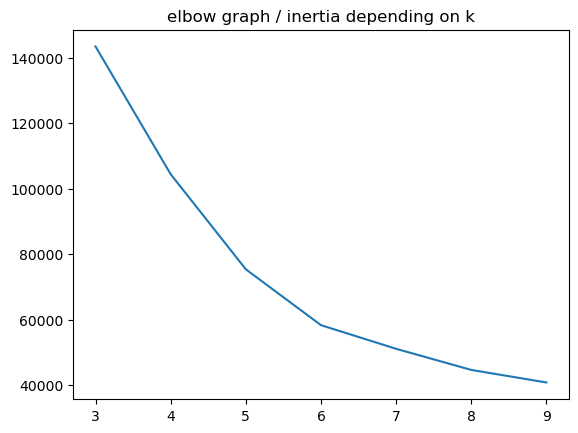

In [39]:
# sns.lineplot(range(3, 10), km_inertias) PHUOCNT
sns.lineplot(x=range(3, 10), y=km_inertias)
plt.title('elbow graph / inertia depending on k')
plt.show()

### 4. Tìm số cụm tối ưu bằng phương pháp Silhoutte

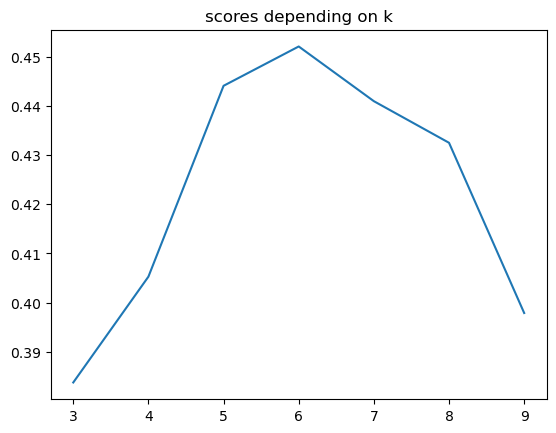

In [40]:
sns.lineplot(x=range(3, 10), y=km_scores)
plt.title('scores depending on k')
plt.show()

### 5. Gán nhãn cho các mẫu dữ liệu dựa vào mô hình K-Means với số cụm là 6

In [41]:
km = KMeans(n_clusters=6).fit(X)

In [43]:
#Assign the Cluster Labels to the Data
X['Label'] = km.labels_
#Info for each cluster
for k in range(6):
    print(f'Cluster nb : {k}')
    print(X[X.Label == k].describe().iloc[:, 1:-1])
    print('\n\n')

Cluster nb : 0
             Age  Annual Income (k$)  Spending Score (1-100)
count  45.000000           45.000000               45.000000
mean   56.155556           53.377778               49.088889
std     8.543886            8.435016                6.251626
min    43.000000           38.000000               35.000000
25%    49.000000           47.000000               45.000000
50%    54.000000           54.000000               49.000000
75%    65.000000           62.000000               55.000000
max    70.000000           67.000000               60.000000



Cluster nb : 1
             Age  Annual Income (k$)  Spending Score (1-100)
count  39.000000           39.000000               39.000000
mean   32.692308           86.538462               82.128205
std     3.728650           16.312485                9.364489
min    27.000000           69.000000               63.000000
25%    30.000000           75.500000               74.500000
50%    32.000000           79.000000               8

## Bài mẫu 2: Iris.csv

### 1. Import thư viện và load dữ liệu

In [45]:
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

iris = pd.read_csv("Iris.csv")
iris.drop('Id',inplace=True,axis=1)

X = iris.iloc[:,:-1].values #Set our training data
y = iris.iloc[:,-1].values #We'll use this just for visualization as clustering doesn't require labels

iris.head().style.background_gradient(cmap = sns.cubehelix_palette(as_cmap=True))

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.100000,3.500000,1.400000,0.200000,Iris-setosa
1,4.900000,3.000000,1.400000,0.200000,Iris-setosa
2,4.700000,3.200000,1.300000,0.200000,Iris-setosa
3,4.600000,3.100000,1.500000,0.200000,Iris-setosa
4,5.000000,3.600000,1.400000,0.200000,Iris-setosa


### 2. EDA và xử lý dữ liệu

In [46]:
# Data Distribution => The Data is perfectly balanced
fig = px.pie(iris,
'Species',color_discrete_sequence=['#491D8B','#7D3AC1','#EB548C'],title=
'Data Distribution',template='plotly')
fig.show()

# Phân tích biến Sepal-Length với box-plot
fig = px.box(data_frame=iris, x='Species',y='SepalLengthCm',
            color='Species', color_discrete_sequence=['#29066B','#7D3AC1','#EB548C'],
            orientation='v')
fig.show()

# Phân tích biến SepalLengthCm với histogram
fig = px.histogram(data_frame=iris, x='SepalLengthCm',
            color='Species',
            color_discrete_sequence=['#491D8B','#7D3AC1','#EB548C'],
            nbins=50)
fig.show()

# Phân tích biến SepalWidth với box plot
fig = px.box(data_frame=iris, x='Species',
            y='SepalWidthCm', color='Species',
            color_discrete_sequence=['#29066B','#7D3AC1','#EB548C'],
            orientation='v')
fig.show()

# Phân tích 2 biến SepalLengthCm và SepalWidthCm
fig = px.scatter(data_frame=iris, x='SepalLengthCm',y='SepalWidthCm'
            ,color='Species',size='PetalLengthCm',
            template='seaborn',
            color_discrete_sequence=['#491D8B','#7D3AC1','#EB548C'],)
fig.update_layout(width=800, height=600,
            xaxis=dict(color="#BF40BF"),
            yaxis=dict(color="#BF40BF"))
fig.show()

# Phân tích 2 biến PetalLengthCm và PetalWidthCm
fig = px.scatter(data_frame=iris, x='PetalLengthCm',y='PetalWidthCm'
            ,color='Species',size='SepalLengthCm',
            template='seaborn',
            color_discrete_sequence=['#491D8B','#7D3AC1','#EB548C'],)
fig.update_layout(width=800, height=600,
            xaxis=dict(color="#BF40BF"),
            yaxis=dict(color="#BF40BF"))
fig.show()

### 3. Tìm số cluster tối ưu cho mô hình K-Means

In [47]:
sse = []
for i in range(1,9):
    kmeans = KMeans(n_clusters=i , max_iter=300)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)
fig = px.line(y=sse,template="seaborn",title='Eblow Method')
fig.update_layout(width=800, height=600,
title_font_color="#BF40BF",
xaxis=dict(color="#BF40BF",title="Clusters"),
yaxis=dict(color="#BF40BF",title="SSE"))
# Cluster = 3 là số cluster tối ưu cho dữ liệu Iris

### 4. Xây dựng mô hình K-Means với số cluster tối ưu = 3

In [48]:
kmeans = KMeans(n_clusters = 3,
init = 'k-means++',
max_iter = 300, n_init = 10, random_state = 0)
clusters = kmeans.fit_predict(X)

### 5. Trình bày kết quả trực quan các cluster

In [49]:
fig = go.Figure()
fig.add_trace(go.Scatter(
x=X[clusters == 0, 0], y=X[clusters == 0, 1],
mode='markers',marker_color='#DB4CB2',name='Iris-setosa'
))
fig.add_trace(go.Scatter(
x=X[clusters == 1, 0], y=X[clusters == 1, 1],
mode='markers',marker_color='#c9e9f6',name='Iris-versicolour'
))
fig.add_trace(go.Scatter(
x=X[clusters == 2, 0], y=X[clusters == 2, 1],
mode='markers',marker_color='#7D3AC1',name='Iris-virginica'
))
fig.add_trace(go.Scatter(
x=kmeans.cluster_centers_[:, 0], y= kmeans.cluster_centers_[:,1],
mode='markers',marker_color='#CAC9CD',marker_symbol=4,
marker_size=13,name='Centroids'
))
fig.update_layout(template='plotly_dark',width=1000,
height=500,title='Kmean Clustering Results')

## Thực hành 1: Penguins.csv

### 1. Import thư viện và tập dữ liệu

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv("penguins.csv")
df.info()
df.head().style.background_gradient(cmap=sns.cubehelix_palette(as_cmap=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   342 non-null    float64
 1   culmen_depth_mm    342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
 4   sex                335 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.6+ KB


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.100000,18.700000,181.000000,3750.000000,MALE
1,39.500000,17.400000,186.000000,3800.000000,FEMALE
2,40.300000,18.000000,195.000000,3250.000000,FEMALE
3,nan,nan,nan,nan,nan
4,36.700000,19.300000,193.000000,3450.000000,FEMALE


### 2. Tiền xử lí dữ liệu

In [2]:
# Chuyển đổi giới tính: Male=1, Female=0
df['sex'] = df['sex'].map({'MALE': 1, "FEMALE": 0})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   342 non-null    float64
 1   culmen_depth_mm    342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
 4   sex                334 non-null    float64
dtypes: float64(5)
memory usage: 13.6 KB


In [3]:
print("Số lượng giá trị bị thiếu trên mỗi cột:")
print(df.isnull().sum())

Số lượng giá trị bị thiếu trên mỗi cột:
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64


In [4]:
# Các hàng bị thiếu tất cả các giá trị bị thiếu sẽ bị loại bỏ
df = df.dropna(how='all')
print(df.isnull().sum())

culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  8
dtype: int64


In [5]:
# Dùng Naive Bayes để ước lượng các giá trị bị thiếu
from sklearn.naive_bayes import GaussianNB

# Tạo DataFrame với các hàng không có giá trị thiếu để huấn luyện
df_no_missing = df.dropna()

# Huấn luyện mô hình với dữ liệu đầy đủ
X_train = df_no_missing.drop("sex", axis=1)
y_train = df_no_missing["sex"]

model = GaussianNB()
model.fit(X_train, y_train)

# Dự đoán giá trị sex cho các hàng bị thiếu
df_missing = df[df.isnull().any(axis=1)]
if len(df_missing) > 0:
    X_missing = df_missing.drop("sex", axis=1).fillna(df_missing.mean())
    predictions = model.predict(X_missing)
    df.loc[df.isnull().any(axis=1), "sex"] = predictions

print("Số lượng giá trị bị thiếu sau khi điền:")
print(df.isnull().sum())

Số lượng giá trị bị thiếu sau khi điền:
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


In [6]:
print("\nSố lượng hàng bị trùng lặp:")
print(df.duplicated().sum())


Số lượng hàng bị trùng lặp:
0


In [7]:
# Xem các dòng có ít nhất một giá trị âm trong các cột số
negative_rows = df[
    (df['culmen_length_mm'] < 0) | 
    (df['culmen_depth_mm'] < 0) | 
    (df['flipper_length_mm'] < 0) | 
    (df['body_mass_g'] < 0)
]

print("Các hàng chứa dữ liệu âm:")
display(negative_rows)

Các hàng chứa dữ liệu âm:


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
14,34.6,21.1,-132.0,4400.0,1.0


In [8]:
drop_indices = negative_rows.index
df = df.drop(drop_indices).reset_index(drop=True)

### 3. EDA

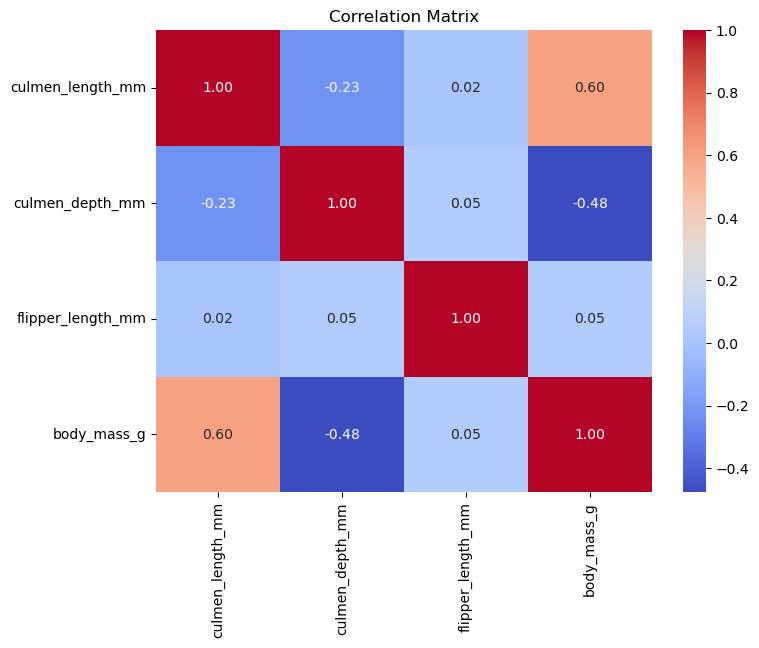

d:\code\anaconda\ana\Lib\site-packages\kaleido\_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




In [9]:
# Heatmap: Xem tương quan giữa các biến
plt.figure(figsize=(8, 6))
sns.heatmap(df[['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']].corr(), 
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Pairplot: Phân bố các cụm
fig = px.scatter_matrix(
    df,
    dimensions=['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g'],
    color="sex",
    title="Scatter Matrix (Tổng quan dữ liệu)",
    color_discrete_sequence=['#491D8B', '#EB548C']
)
fig.update_traces(diagonal_visible=False)
fig.show()

In [10]:
my_colors = ['#491D8B', '#EB548C']

# 1. Biểu đồ tròn
fig = px.pie(df, 'sex', 
             color_discrete_sequence=my_colors,
             title='Data Distribution (Sex)', 
             template='plotly')
fig.show()

# 2. Box-plot: Chiều dài mỏ
fig = px.box(data_frame=df, x='sex', y='culmen_length_mm',
             color='sex',
             color_discrete_sequence=my_colors,
             orientation='v',
             title='Box-plot: Culmen Length by Sex')
fig.show()

# 3. Histogram: Chiều dài mỏ
fig = px.histogram(data_frame=df, x='culmen_length_mm',
                   color='sex',
                   color_discrete_sequence=my_colors,
                   nbins=50,
                   title='Histogram: Culmen Length Distribution')
fig.show()

# 4. Box-plot: Độ sâu mỏ
fig = px.box(data_frame=df, x='sex', y='culmen_depth_mm', 
             color='sex',
             color_discrete_sequence=my_colors,
             orientation='v',
             title='Box-plot: Culmen Depth by Sex')
fig.show()

# 5. Scatter Plot: Chiều dài mỏ vs Độ sâu mỏ
fig = px.scatter(data_frame=df, x='culmen_length_mm', y='culmen_depth_mm',
                 color='sex', size='flipper_length_mm',
                 template='seaborn',
                 color_discrete_sequence=my_colors,
                 title='Scatter: Culmen Length vs Depth')
fig.update_layout(width=800, height=600,
                  xaxis=dict(color="#BF40BF"), yaxis=dict(color="#BF40BF"))
fig.show()

# 6. Scatter Plot: Cánh vs Cân nặng (Sẽ thấy rõ tương quan sau khi sửa)
fig = px.scatter(data_frame=df, x='flipper_length_mm', y='body_mass_g',
                 color='sex', size='culmen_length_mm',
                 template='seaborn',
                 color_discrete_sequence=my_colors,
                 title='Scatter: Flipper Length vs Body Mass')
fig.update_layout(width=800, height=600,
                  xaxis=dict(color="#BF40BF"), yaxis=dict(color="#BF40BF"))
fig.show()


### 4. Tìm số cụm tối ưu và huấn luyện mô hình

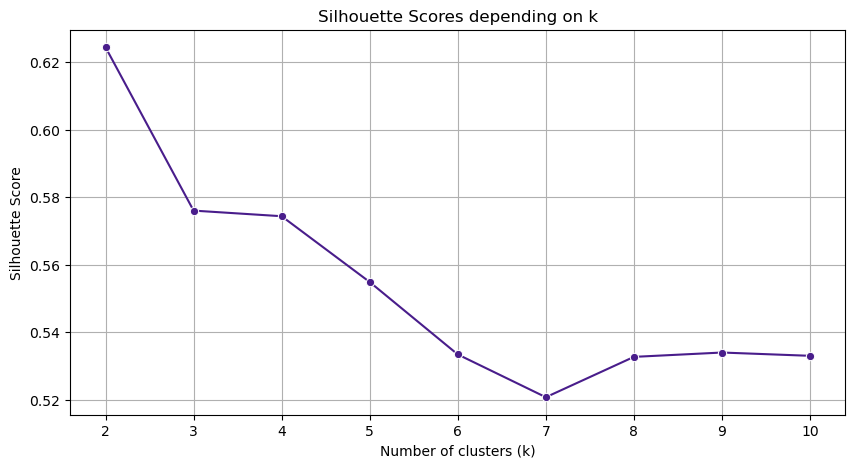

Số cụm tối ưu theo Silhouette là: k=2 với score=0.6244


In [11]:
X = df.drop('sex', axis=1)
from sklearn.metrics import silhouette_score

#  Tính toán Silhouette Score 
km_scores = []
k_range = range(2, 11)  

for i in k_range:
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(df) 
    
    # Tính score và lưu lại
    score = silhouette_score(df, kmeans.labels_)
    km_scores.append(score)

# Vẽ biểu đồ Silhouette (Code của bạn) 
plt.figure(figsize=(10, 5))
sns.lineplot(x=k_range, y=km_scores, marker='o', color='#491D8B') # Thêm marker='o' cho dễ nhìn
plt.title('Silhouette Scores depending on k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

# In ra k tối ưu theo Silhouette
best_k = k_range[np.argmax(km_scores)]
print(f"Số cụm tối ưu theo Silhouette là: k={best_k} với score={max(km_scores):.4f}")

# Phương pháp Elbow 
sse = []
for i in range(1, 11): 
    kmeans = KMeans(n_clusters=i, max_iter=300, random_state=42, n_init=10)
    kmeans.fit(df)
    sse.append(kmeans.inertia_)

fig = px.line(x=range(1, 11), y=sse, template="seaborn", title='Elbow Method')
fig.update_layout(width=800, height=600, 
                  title_font_color="#BF40BF",
                  xaxis=dict(color="#BF40BF", title="Clusters"),
                  yaxis=dict(color="#BF40BF", title="SSE"))
fig.show()

#  Chạy mô hình cuối cùng 
# Bạn có thể chọn k=4 hoặc k theo best_k tìm được ở trên
kmeans_final = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=0)
clusters = kmeans_final.fit_predict(df)

In [12]:
# Chạy K-means với k=2
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

# Vẽ kết quả clustering 
fig = go.Figure()

colors = ['#FF6B6B', '#4ECDC4']  # Màu cho 2 cụm

for i in range(2):
    fig.add_trace(go.Scatter(
        x=X[clusters == i].iloc[:, 0],  
        y=X[clusters == i].iloc[:, 1],  
        mode='markers',
        marker=dict(color=colors[i], size=10, opacity=0.8),
        name=f'Cụm {i}'
    ))

# Vẽ tâm cụm
fig.add_trace(go.Scatter(
    x=kmeans.cluster_centers_[:, 0],
    y=kmeans.cluster_centers_[:, 1],
    mode='markers+text',
    marker=dict(color='white', size=14, symbol='x', line=dict(width=3, color='yellow')),
    text=[f'Center {i}' for i in range(2)],
    textposition='bottom center',
    name='Tâm cụm'
))

fig.update_layout(
    template='plotly_dark',
    width=1000,
    height=600,
    title='<b>K-Means Clustering Results (k=2)</b>',
    #xaxis_title='Chiều dài mỏ (culmen_length_mm)',
    #yaxis_title='Độ sâu mỏ (culmen_depth_mm)',
    legend_title='Nhóm'
)
fig.show()

# Phân tích tỷ lệ giới tính trong từng cụm (liên kết với dự đoán giới tính)
df['cluster'] = clusters
print(df.groupby('cluster')['sex'].value_counts(normalize=True).unstack().fillna(0))



sex           0.0       1.0
cluster                    
0        0.574163  0.425837
1        0.401515  0.598485


## Thực hành 2: OnlineRetail.csv

### 1. Import thư viện và tập dữ liệu

In [13]:
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv("OnlineRetail.csv", encoding='latin-1')
df.info()
df.head().style.background_gradient(cmap=sns.cubehelix_palette(as_cmap=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.550000,17850.000000,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.390000,17850.000000,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.750000,17850.000000,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.390000,17850.000000,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.390000,17850.000000,United Kingdom


### 2. Tiền xử lí dữ liệu

In [14]:
print("Số lượng giá trị bị thiếu trên mỗi cột:")
print(df.isnull().sum())

Số lượng giá trị bị thiếu trên mỗi cột:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [15]:
print("\nSố lượng hàng bị trùng lặp:")
print(df.duplicated().sum())
print(df[df.duplicated()])


Số lượng hàng bị trùng lặp:
5268
       InvoiceNo StockCode                        Description  Quantity  \
517       536409     21866        UNION JACK FLAG LUGGAGE TAG         1   
527       536409     22866      HAND WARMER SCOTTY DOG DESIGN         1   
537       536409     22900    SET 2 TEA TOWELS I LOVE LONDON          1   
539       536409     22111       SCOTTIE DOG HOT WATER BOTTLE         1   
555       536412     22327  ROUND SNACK BOXES SET OF 4 SKULLS         1   
...          ...       ...                                ...       ...   
541675    581538     22068        BLACK PIRATE TREASURE CHEST         1   
541689    581538     23318     BOX OF 6 MINI VINTAGE CRACKERS         1   
541692    581538     22992             REVOLVER WOODEN RULER          1   
541699    581538     22694                       WICKER STAR          1   
541701    581538     23343       JUMBO BAG VINTAGE CHRISTMAS          1   

             InvoiceDate  UnitPrice  CustomerID         Country  

In [16]:
# Xóa hàng CustomerID bị thiếu và thay thế giá trị thiếu trong Description
df.dropna(subset=['CustomerID'], inplace=True)
df['Description'] = df['Description'].fillna('No Description')
df.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [17]:
# Chuyển đổi kiểu dữ liệu
df = df[~df['InvoiceNo'].astype(str).str.contains('C', na=False)]
df['InvoiceNo'] = df['InvoiceNo'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='mixed')
df['CustomerID'] = df['CustomerID'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397924 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397924 non-null  int64         
 1   StockCode    397924 non-null  object        
 2   Description  397924 non-null  object        
 3   Quantity     397924 non-null  int64         
 4   InvoiceDate  397924 non-null  datetime64[ns]
 5   UnitPrice    397924 non-null  float64       
 6   CustomerID   397924 non-null  int64         
 7   Country      397924 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(3)
memory usage: 27.3+ MB


### 3. Kỹ thuật đặc trưng

In [18]:
# Tính tổng tiền cho mỗi đơn hàng
df['Amount'] = df['Quantity'] * df['UnitPrice']
Cid_amount = df.groupby('CustomerID')['Amount'].sum().reset_index()
Cid_amount.head()

,CustomerID,Amount
0,12346,77183.60
1,12347,4310.00
2,12348,1797.24
3,12349,1757.55
4,12350,334.40


In [19]:
# Tính số lần mua hàng của mỗi khách hàng
freq = df.groupby('CustomerID')['InvoiceNo'].count().reset_index()
freq.columns = ['CustomerID', 'Frequency']
freq.head()

,CustomerID,Frequency
0,12346,1
1,12347,182
2,12348,31
3,12349,73
4,12350,17


In [20]:
# Kết hợp dữ liệu 
rfm = pd.merge(Cid_amount, freq, on='CustomerID', how='inner')
rfm.head()

,CustomerID,Amount,Frequency
0,12346,77183.60,1
1,12347,4310.00,182
2,12348,1797.24,31
3,12349,1757.55,73
4,12350,334.40,17


In [21]:
# Tính thời gian kể từ lần mua hàng cuối cùng
df['dif'] = max(df['InvoiceDate']) - df['InvoiceDate']
df['dif'] = df['dif'].dt.days
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount,dif
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-01-12 08:26:00,2.55,17850,United Kingdom,15.30,697
1,536365,71053,WHITE METAL LANTERN,6,2010-01-12 08:26:00,3.39,17850,United Kingdom,20.34,697
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-01-12 08:26:00,2.75,17850,United Kingdom,22.00,697
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-01-12 08:26:00,3.39,17850,United Kingdom,20.34,697
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-01-12 08:26:00,3.39,17850,United Kingdom,20.34,697


In [22]:
# Lấy giá trị thời gian kể từ lần mua hàng cuối cùng cho mỗi khách hàng
last = df.groupby('CustomerID')['dif'].min().reset_index()
last.head()

,CustomerID,dif
0,12346,326
1,12347,40
2,12348,76
3,12349,19
4,12350,311


In [23]:
# Bảng RFM hoàn chỉnh
rfm = pd.merge(rfm, last, on='CustomerID', how='inner')
rfm.columns = ['CustomerID', 'Amount', 'Frequency', 'Recency']
rfm.head()

,CustomerID,Amount,Frequency,Recency
0,12346,77183.60,1,326
1,12347,4310.00,182,40
2,12348,1797.24,31,76
3,12349,1757.55,73,19
4,12350,334.40,17,311


### 4. EDA

In [24]:
rfm.describe()

,CustomerID,Amount,Frequency,Recency
count,4339.000000,4339.000000,4339.000000,4339.000000
mean,15299.936852,2053.793018,91.708689,105.430053
std,1721.889758,8988.248381,228.792852,115.075862
min,12346.000000,0.000000,1.000000,0.000000
25%,13812.500000,307.245000,17.000000,22.000000
50%,15299.000000,674.450000,41.000000,61.000000
75%,16778.500000,1661.640000,100.000000,161.500000
max,18287.000000,280206.020000,7847.000000,697.000000


In [25]:
# Phát hiện ngoại lệ sử dụng IQR
Q1 = rfm[['Recency', 'Frequency', 'Amount']].quantile(0.25)
Q3 = rfm[['Recency', 'Frequency', 'Amount']].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [26]:
# Lọc bỏ ngoại lệ
filtered = rfm[
    (rfm['Recency'] >= lower['Recency']) & (rfm['Recency'] <= upper['Recency']) &
    (rfm['Frequency'] >= lower['Frequency']) & (rfm['Frequency'] <= upper['Frequency']) &
    (rfm['Amount'] >= lower['Amount']) & (rfm['Amount'] <= upper['Amount'])
]

In [27]:
filtered.describe()

,CustomerID,Amount,Frequency,Recency
count,3682.000000,3682.000000,3682.000000,3682.000000
mean,15312.727594,843.231226,50.756382,106.373438
std,1714.182234,784.852084,47.376080,96.497657
min,12348.000000,0.000000,1.000000,0.000000
25%,13827.250000,281.935000,15.000000,25.000000
50%,15312.500000,570.480000,34.000000,72.000000
75%,16799.000000,1142.847500,73.000000,172.000000
max,18287.000000,3692.280000,223.000000,363.000000


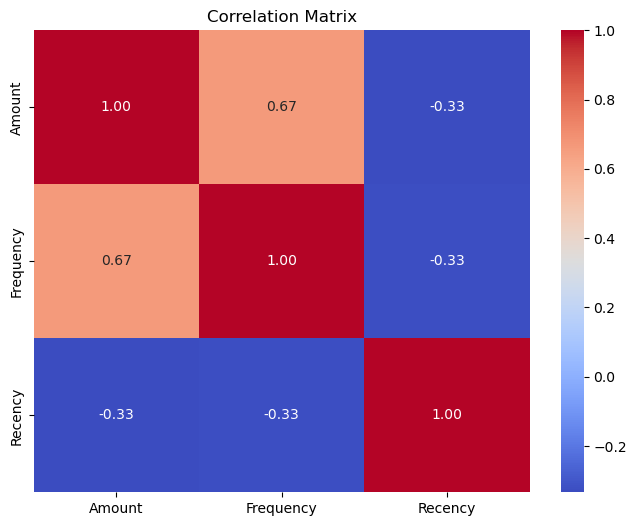

In [28]:
# Heatmap: Xem tương quan giữa các biến
plt.figure(figsize=(8, 6))
sns.heatmap(filtered[['Amount', 'Frequency', 'Recency']].corr(), 
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Pairplot: Phân bố các cụm
fig = px.scatter_matrix(
    filtered,
    dimensions=['Amount', 'Frequency', 'Recency'],
    color="CustomerID",
    title="Scatter Matrix (Tổng quan dữ liệu)",
    color_discrete_sequence=['#491D8B', '#EB548C']
)
fig.update_traces(diagonal_visible=False)
fig.show()

In [29]:
main_color = ['#491D8B'] 

# --- RECENCY ---

# 1. Box-plot: Recency
fig = px.box(data_frame=filtered, 
             y='Recency', 
             color_discrete_sequence=main_color,
             title='Box-plot: Recency Distribution')
fig.show()

# 2. Histogram: Recency Distribution
fig = px.histogram(data_frame=filtered, 
                   x='Recency',
                   color_discrete_sequence=main_color,
                   nbins=50,
                   title='Histogram: Recency Distribution')
fig.update_layout(bargap=0.1) 
fig.show()

# --- AMOUNT ---

# 3. Box-plot: Amount
fig = px.box(data_frame=filtered, 
             y='Amount',
             color_discrete_sequence=main_color,
             title='Box-plot: Amount Distribution')
fig.show()

# 4. Histogram: Amount Distribution
fig = px.histogram(data_frame=filtered, 
                   x='Amount',
                   color_discrete_sequence=main_color,
                   nbins=50,
                   title='Histogram: Amount Distribution')
fig.update_layout(bargap=0.1)
fig.show()

# --- FREQUENCY ---

# 5. Box-plot: Frequency
fig = px.box(data_frame=filtered, 
             y='Frequency', 
             color_discrete_sequence=main_color,
             title='Box-plot: Frequency Distribution')
fig.show()

# 6. Histogram: Frequency Distribution
fig = px.histogram(data_frame=filtered, 
                   x='Frequency',
                   color_discrete_sequence=main_color,
                   nbins=50,
                   title='Histogram: Frequency Distribution')
fig.update_layout(bargap=0.1)
fig.show()

# --- SCATTER PLOTS (Tương quan) ---

# 7. Scatter Plot: Recency vs Frequency
fig = px.scatter(data_frame=filtered, 
                 x='Recency', y='Frequency',
                 size='Amount',           # Kích thước điểm dựa trên tổng tiền mua
                 hover_name='CustomerID', 
                 template='seaborn',
                 color_discrete_sequence=main_color,
                 title='Scatter: Recency vs Frequency (Size = Amount)')
fig.update_layout(width=800, height=600,
                  xaxis=dict(color="#BF40BF"), yaxis=dict(color="#BF40BF"))
fig.show()

# 8. Scatter Plot: Recency vs Amount
fig = px.scatter(data_frame=filtered, 
                 x='Recency', y='Amount',
                 size='Frequency',        # Kích thước điểm dựa trên tần suất mua
                 hover_name='CustomerID', 
                 template='seaborn',
                 color_discrete_sequence=main_color,
                 title='Scatter: Recency vs Amount (Size = Frequency)')
fig.update_layout(width=800, height=600,
                  xaxis=dict(color="#BF40BF"), yaxis=dict(color="#BF40BF"))
fig.show()

### 5. Tìm số cụm tối ưu và huấn luyện mô hình

In [30]:
from sklearn.preprocessing import StandardScaler

rfm = filtered[['Amount', 'Frequency', 'Recency']]
scaler = StandardScaler()
rfm_scaled_array = scaler.fit_transform(rfm)

rfm_scaled = pd.DataFrame(
    rfm_scaled_array, 
    columns=['Amount', 'Frequency', 'Recency'],
    index=rfm.index  
)

rfm_scaled.head()


,Amount,Frequency,Recency
2,1.215692,-0.417068,-0.314801
3,1.165115,0.469575,-0.905569
4,-0.648403,-0.712616,2.120822
5,2.118915,0.722902,-0.345894
6,-0.961116,-0.987054,1.011836


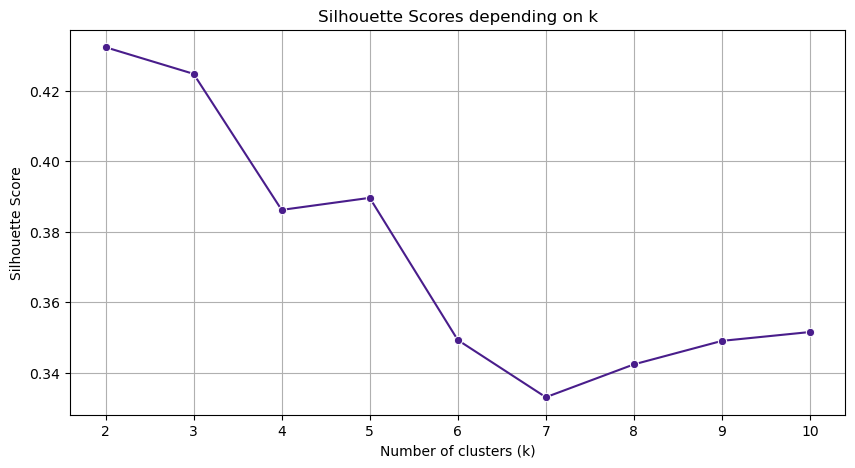

In [31]:
from sklearn.metrics import silhouette_score

#  Tính toán Silhouette Score 
km_scores = []
k_range = range(2, 11)  

for i in k_range:
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled) 
    
    # Tính score và lưu lại
    score = silhouette_score(rfm_scaled, kmeans.labels_)
    km_scores.append(score)

# Vẽ biểu đồ Silhouette (Code của bạn) 
plt.figure(figsize=(10, 5))
sns.lineplot(x=k_range, y=km_scores, marker='o', color='#491D8B') # Thêm marker='o' cho dễ nhìn
plt.title('Silhouette Scores depending on k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

# Phương pháp Elbow 
sse = []
for i in range(1, 11): 
    kmeans = KMeans(n_clusters=i, max_iter=300, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    sse.append(kmeans.inertia_)

fig = px.line(x=range(1, 11), y=sse, template="seaborn", title='Elbow Method')
fig.update_layout(width=800, height=600, 
                  title_font_color="#BF40BF",
                  xaxis=dict(color="#BF40BF", title="Clusters"),
                  yaxis=dict(color="#BF40BF", title="SSE"))
fig.show()



In [32]:
#  Chạy mô hình cuối cùng 
kmeans_final = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=0)
clusters = kmeans_final.fit_predict(rfm_scaled)

In [33]:
import plotly.graph_objects as go

model_used = kmeans_final 
fig = go.Figure()

colors = ['#FF6B6B', '#4ECDC4', '#FFD93D']  # Màu cho 3 cụm

# 1. Vẽ các điểm dữ liệu (Scatter 3D)
for i in range(3):
    fig.add_trace(go.Scatter3d(
        x=rfm_scaled.iloc[clusters == i, 0], # Cột Amount
        y=rfm_scaled.iloc[clusters == i, 1], # Cột Frequency
        z=rfm_scaled.iloc[clusters == i, 2], # Cột Recency (Trục thứ 3)
        mode='markers',
        marker=dict(color=colors[i], size=4, opacity=0.6), # Giảm size và opacity để dễ nhìn xuyên thấu
        name=f'Cụm {i}'
    ))

# 2. Vẽ tâm cụm (Centroids) 
fig.add_trace(go.Scatter3d(
    x=model_used.cluster_centers_[:, 0],
    y=model_used.cluster_centers_[:, 1],
    z=model_used.cluster_centers_[:, 2],
    mode='markers+text',
    marker=dict(color='white', size=10, symbol='x', line=dict(width=5, color='yellow')),
    text=[f'Center {i}' for i in range(3)],
    name='Tâm cụm'
))

fig.update_layout(
    template='plotly_dark',
    width=1000, height=800,
    title='<b>K-Means Clustering Results (3D View)</b>',
    scene=dict(
        xaxis_title='Amount (Scaled)',
        yaxis_title='Frequency (Scaled)',
        zaxis_title='Recency (Scaled)'
    )
)
fig.show()

In [34]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

centers = kmeans_final.cluster_centers_

# Xác định thứ tự cột trong rfm_scaled 
# 0: Amount, 1: Frequency, 2: Recency
cols = ['Amount', 'Frequency', 'Recency']
colors = ['#FF6B6B', '#4ECDC4', '#FFD93D'] # Màu cho 3 cụm

# Tạo khung 3 biểu đồ con (1 hàng 3 cột)
fig = make_subplots(rows=1, cols=3, 
                    subplot_titles=('Amount vs Frequency', 'Frequency vs Recency', 'Recency vs Amount'))

# --- VÒNG LẶP VẼ TỪNG CỤM ---
for i in range(3): # Lặp qua 3 cụm (0, 1, 2)
    mask = (clusters == i) # Lọc dữ liệu thuộc cụm i
    
    # Biểu đồ 1: Amount (x) vs Frequency (y)
    fig.add_trace(go.Scatter(
        x=rfm_scaled.loc[mask, 'Amount'], 
        y=rfm_scaled.loc[mask, 'Frequency'],
        mode='markers', marker=dict(color=colors[i], size=6, opacity=0.6),
        name=f'Cụm {i}', showlegend=(i==0) 
    ), row=1, col=1)

    # Biểu đồ 2: Frequency (x) vs Recency (y)
    fig.add_trace(go.Scatter(
        x=rfm_scaled.loc[mask, 'Frequency'], 
        y=rfm_scaled.loc[mask, 'Recency'],
        mode='markers', marker=dict(color=colors[i], size=6, opacity=0.6),
        name=f'Cụm {i}', showlegend=False
    ), row=1, col=2)

    # Biểu đồ 3: Recency (x) vs Amount (y)
    fig.add_trace(go.Scatter(
        x=rfm_scaled.loc[mask, 'Recency'], 
        y=rfm_scaled.loc[mask, 'Amount'],
        mode='markers', marker=dict(color=colors[i], size=6, opacity=0.6),
        name=f'Cụm {i}', showlegend=False
    ), row=1, col=3)

# --- VẼ TÂM CỤM (CENTROIDS) ---
# Tâm biểu đồ 1 (Cột 0 vs Cột 1)
fig.add_trace(go.Scatter(
    x=centers[:, 0], y=centers[:, 1],
    mode='markers', marker=dict(color='black', size=12, symbol='x', line=dict(width=2, color='white')),
    name='Tâm cụm'
), row=1, col=1)

# Tâm biểu đồ 2 (Cột 1 vs Cột 2)
fig.add_trace(go.Scatter(
    x=centers[:, 1], y=centers[:, 2],
    mode='markers', marker=dict(color='black', size=12, symbol='x', line=dict(width=2, color='white')),
    showlegend=False
), row=1, col=2)

# Tâm biểu đồ 3 (Cột 2 vs Cột 0)
fig.add_trace(go.Scatter(
    x=centers[:, 2], y=centers[:, 0],
    mode='markers', marker=dict(color='black', size=12, symbol='x', line=dict(width=2, color='white')),
    showlegend=False
), row=1, col=3)

# Cập nhật giao diện
fig.update_layout(title_text="Phân tích chi tiết từng cặp biến (2D Views)", 
                  template='plotly_dark', height=500, width=1200)
fig.show()